In [1]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from matching import build_roma_matcher, match_two_images_roma
import viz
import raft_stereo

In [2]:
K_rgb_L = np.array([[889.8174, 0, 375.1605], [0, 891.2550, 277.3332], [0, 0, 1]])
D_rgb_L = np.array([-0.20879, 0.14455, -0.00018, 0.00031])

K_rgb_R = np.array([[889.4472, 0, 365.3022], [0, 890.6761, 285.7608], [0, 0, 1]])
D_rgb_R = np.array([-0.20744, 0.14176, 0.00113, -0.00010])

K_ir_L = np.array([[514.1837, 0, 327.5567], [0, 514.0445, 247.3693], [0, 0, 1]])
D_ir_L = np.array([-0.44319, 0.19562, 0.00103, -0.00171])

K_ir_R = np.array([[502.6188, 0, 299.1063], [0, 501.1625, 237.6147], [0, 0, 1]])
D_ir_R = np.array([-0.43438, 0.18212, 0.00317, 0.00299])

# RGB Extrinsics (Right-in-Left)
q_1_0 = np.array([0.01309, -0.01322, -0.00458, 0.99982])
t_1_0 = np.array([0.32019, 0.00262, -0.00701])

path_rgb_L = "/home/nail/stuff/rgb-ir/rgb-ir-extrinsics/frames/frluas3_2025-12-07-23-00-56/frluas3_camera_array_cam1_image_raw/1.png"
path_rgb_R = "/home/nail/stuff/rgb-ir/rgb-ir-extrinsics/frames/frluas3_2025-12-07-23-00-56/frluas3_camera_array_cam0_image_raw/1.png"
path_ir_L  = "/home/nail/stuff/rgb-ir/rgb-ir-extrinsics/frames/frluas3_2025-12-07-23-00-56/frluas3_boson_camera_array_cam_0_image_raw/1.png"
path_ir_R  = "/home/nail/stuff/rgb-ir/rgb-ir-extrinsics/frames/frluas3_2025-12-07-23-00-56/frluas3_boson_camera_array_cam_1_image_raw/1.png"

In [3]:

matcher_api = build_roma_matcher()

*****************cuda, False**************************


/home/nail/miniconda3/envs/gtsam-env/lib/python3.10/site-packages/pytorch_lightning/profiler/__init__.py:36: LightningDeprecationWarning: `pytorch_lightning.profiler.PassThroughProfiler` is deprecated in v1.9.0 and will be removed in v2.0.0. Use the equivalent `pytorch_lightning.profilers.PassThroughProfiler` class instead.
  rank_zero_deprecation(
2025-12-08 11:16:21.048 | INFO     | MatchAnything.src.lightning.lightning_loftr:__init__:76 - Load model from:<All keys matched successfully>
[2025/12/08 11:16:21 hloc INFO] Loading matchanything_roma model done


[2025/12/08 11:16:23 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/12/08 11:16:23 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


[ROMA] Using robust inliers.
[INFO] Inliers OK: 1699 (limit=3000)
Found 1699 matches.


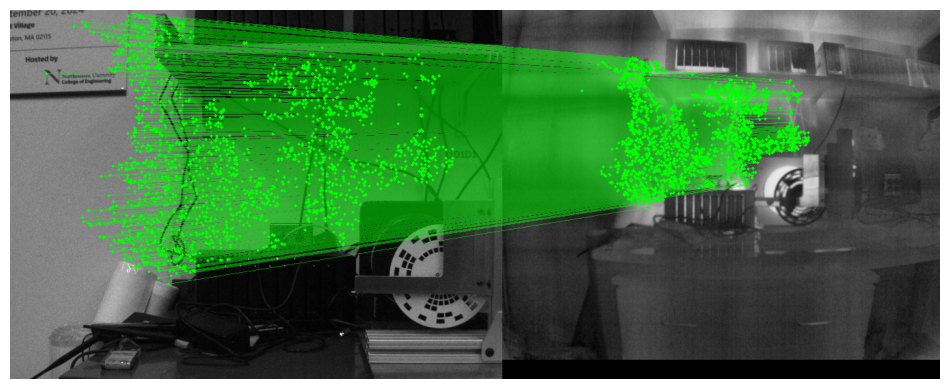

array([[[137, 137, 137],
        [141, 141, 141],
        [138, 138, 138],
        ...,
        [ 74,  74,  74],
        [ 72,  72,  72],
        [ 74,  74,  74]],

       [[136, 136, 136],
        [119, 119, 119],
        [127, 127, 127],
        ...,
        [ 80,  80,  80],
        [ 85,  85,  85],
        [ 88,  88,  88]],

       [[ 96,  96,  96],
        [ 92,  92,  92],
        [125, 125, 125],
        ...,
        [ 88,  88,  88],
        [ 98,  98,  98],
        [ 90,  90,  90]],

       ...,

       [[116, 116, 116],
        [122, 122, 122],
        [122, 122, 122],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[122, 122, 122],
        [118, 118, 118],
        [121, 121, 121],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[118, 118, 118],
        [112, 112, 112],
        [111, 111, 111],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]]

In [4]:
mkpts_rgb, mkpts_ir, mconf, rgb_gray, ir_gray = match_two_images_roma(
    matcher_api, path_rgb_L, path_ir_L, max_inliers=3000
)
print(f"Found {len(mkpts_rgb)} matches.")

viz.visualize_matches(rgb_gray, ir_gray, mkpts_rgb, mkpts_ir)


F-Matrix Inliers: 815 matches.
Visualizing epipolar lines...


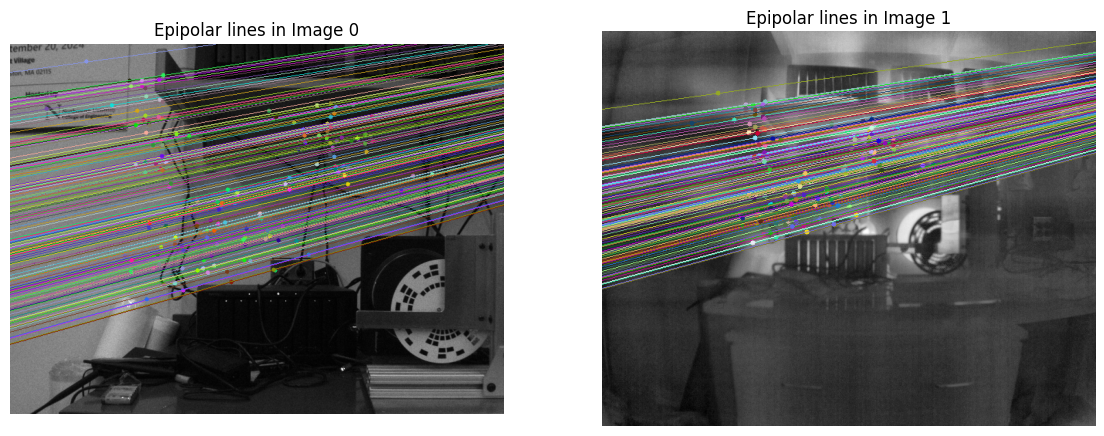

(array([[[137, 137, 137],
         [141, 141, 141],
         [138, 138, 138],
         ...,
         [ 23,  23,  23],
         [ 23,  23,  23],
         [ 24,  24,  24]],
 
        [[136, 136, 136],
         [119, 119, 119],
         [127, 127, 127],
         ...,
         [117, 105, 141],
         [117, 105, 141],
         [117, 105, 141]],
 
        [[ 96,  96,  96],
         [ 92,  92,  92],
         [125, 125, 125],
         ...,
         [ 19,  19,  19],
         [ 22,  22,  22],
         [ 19,  19,  19]],
 
        ...,
 
        [[116, 116, 116],
         [122, 122, 122],
         [122, 122, 122],
         ...,
         [ 73,  73,  73],
         [ 65,  65,  65],
         [ 67,  67,  67]],
 
        [[122, 122, 122],
         [118, 118, 118],
         [121, 121, 121],
         ...,
         [ 80,  80,  80],
         [ 80,  80,  80],
         [ 77,  77,  77]],
 
        [[118, 118, 118],
         [112, 112, 112],
         [111, 111, 111],
         ...,
         [ 93,  93,  93],
  

In [5]:
F, mask = cv2.findFundamentalMat(mkpts_rgb, mkpts_ir, cv2.FM_RANSAC, 0.5, 0.999)
# Filter points to just the inliers of the Fundamental Matrix
mask = mask.ravel().astype(bool)
mkpts_rgb_in = mkpts_rgb[mask]
mkpts_ir_in = mkpts_ir[mask]
print(f"F-Matrix Inliers: {len(mkpts_rgb_in)} matches.")
# 6. Draw Epipolar Lines
print("Visualizing epipolar lines...")
# shows the epipolar lines for the inlier points
viz.show_epipolar_lines(rgb_gray, ir_gray, mkpts_rgb_in, mkpts_ir_in, F, sample_step=5)


Calculated Baseline: 0.3203 m
[Preprocessor] Running Auto-Alignment...
[Preprocessor] Correction applied: 3.600 pixels


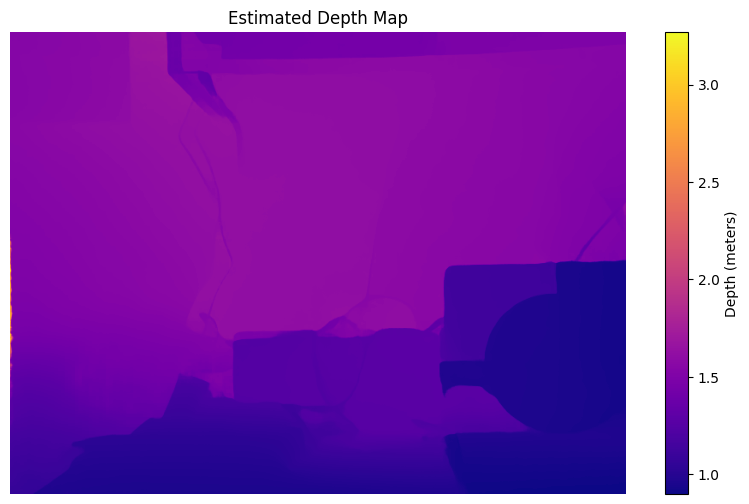

[Point Cloud] Displaying 38863 points (Original: 388800)


In [6]:

model_weights  = '/home/nail/stuff/rgb-ir/rgb-ir-extrinsics/RAFT-Stereo/models/raftstereo-middlebury.pth'

model = raft_stereo.load_raft_model(model_weights)

img_size = (720, 540) # (W, H)
preprocessor = raft_stereo.StereoPreprocessor(
    K_rgb_L, D_ir_L, 
    K_rgb_R, D_rgb_R, 
    q_1_0, t_1_0, 
    img_size
)
print(f"Calculated Baseline: {preprocessor.extrinsics['baseline']:.4f} m")

raw_left = cv2.imread(path_rgb_L)
raw_right = cv2.imread(path_rgb_R)

preprocessor.auto_align(raw_left, raw_right)

rect_left, rect_right = preprocessor.rectify_images(raw_left, raw_right)

depth_map = raft_stereo.estimate_stereo_depth(
    rect_left, 
    rect_right, 
    model, 
    preprocessor.intrinsics, 
    preprocessor.extrinsics
)
depth_map = np.abs(depth_map) # Ensure positive

viz.plot_depth_map(depth_map)   
# viz.plot_point_cloud(depth_map, preprocessor.intrinsics, preprocessor.extrinsics)

pts3d = viz.backproject_depth(depth_map, preprocessor.intrinsics)
viz.plot_point_cloud(pts3d, rect_left, min_z=0.5, max_z=2.0, subsample=10)

In [ ]:
import cv2
import numpy as np

# ==========================================
# 1. RE-MATCHING (Rectified RGB -> Raw IR)
# ==========================================
print("Re-matching on Rectified Image...")


# Run ROMA: Rectified RGB (Left) <-> Raw IR (Left)
mkpts_rgb, mkpts_ir, mconf, rgb_gray, ir_gray = match_two_images_roma(
    matcher_api, rect_left, path_ir_L, max_inliers=3000
)
print(f"Found {len(mkpts_rgb)} matches on rectified image.")

# Optional: Visualize
# viz.visualize_matches(rgb_gray, ir_gray, mkpts_rgb, mkpts_ir)

# ==========================================
# 2. FILTER & BACK-PROJECT
# ==========================================
# Use the depth map (which is already aligned to rect_left)
u = np.round(mkpts_rgb[:, 0]).astype(int)
v = np.round(mkpts_rgb[:, 1]).astype(int)
H, W = depth_map.shape

# A. Bounds Check
valid_uv = (u >= 0) & (u < W) & (v >= 0) & (v < H)
u, v = u[valid_uv], v[valid_uv]
mkpts_rgb = mkpts_rgb[valid_uv]
mkpts_ir = mkpts_ir[valid_uv]

# B. Depth Check (Filter 0.5m - 10m)
z_vals = depth_map[v, u]
valid_z = (z_vals > 0.5) & (z_vals < 10.0)

z_final = z_vals[valid_z]
mkpts_ir_final = mkpts_ir[valid_z]
mkpts_rgb_final = mkpts_rgb[valid_z]

print(f"Points used for PnP: {len(z_final)}")

# C. Back-Project to 3D (Rectified Frame)
# Use the preprocessor's RECTIFIED intrinsics
fx = preprocessor.intrinsics['fx']
fy = preprocessor.intrinsics['fy']
cx = preprocessor.intrinsics['cx1']
cy = preprocessor.intrinsics['cy']

x_3d = (mkpts_rgb_final[:, 0] - cx) * z_final / fx
y_3d = (mkpts_rgb_final[:, 1] - cy) * z_final / fy
z_3d = z_final

object_points = np.stack([x_3d, y_3d, z_3d], axis=1)

# ==========================================
# 3. SOLVE PNP
# ==========================================
print("Solving PnP...")

# Use the Raw IR Intrinsics (K_ir_L, D_ir_L) defined in your snippet
success, rvec, tvec, inliers = cv2.solvePnPRansac(
    object_points,
    mkpts_ir_final,
    K_ir_L,
    D_ir_L,
    iterationsCount=5000,
    reprojectionError=2.0,
    flags=cv2.SOLVEPNP_ITERATIVE
)

if success:
    print("\n=== PnP SUCCESS ===")
    
    # 4. Recover Physical Transformation (Raw RGB -> Raw IR)
    # T_phys = T_pnp * T_rect
    # T_rect (Raw->Rect) is purely rotation R1 for the Left Camera
    
    R_pnp, _ = cv2.Rodrigues(rvec)
    R_physical = R_pnp @ preprocessor.R1 
    t_physical = tvec.flatten()
    
    dist_cm = np.linalg.norm(t_physical) * 100
    print(f"Translation Vector: {t_physical}")
    print(f"Distance:           {dist_cm:.2f} cm")
    print(f"Rotation Matrix:\n{R_physical}")
    
    # Reprojection Error
    if inliers is not None:
            idx = inliers.flatten()
            
            # Project 3D points back to 2D
            proj_pts, _ = cv2.projectPoints(object_points[idx], rvec, tvec, K_ir_L, D_ir_L)
            proj_pts = proj_pts.squeeze() # Shape (N, 2)
            
            measured_pts = mkpts_ir_final[idx] # Shape (N, 2)
            
            # Calculate distances
            errors = np.linalg.norm(measured_pts - proj_pts, axis=1)
            mean_err = np.mean(errors)
            print(f"Reprojection Error: {mean_err:.2f} px")
else:
    print("PnP Failed.")

Re-matching on Rectified Image...


[2025/12/08 11:19:43 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/12/08 11:19:43 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


[ROMA] Using robust inliers.
[INFO] Inliers OK: 1391 (limit=3000)
Found 1391 matches on rectified image.
Points used for PnP: 1391
Solving PnP...

=== PnP SUCCESS ===
Translation Vector: [-0.01067078 -0.0419407   0.02437551]
Distance:           4.97 cm
Rotation Matrix:
[[ 0.99844642 -0.00642964 -0.05534807]
 [ 0.00506296  0.99967968 -0.02479743]
 [ 0.05548978  0.02447868  0.99815914]]
Reprojection Error: 0.94 px
